This is a notebook for testing different filters for types of runs (homings/escapes)
- good vs error
- long vs short

for quality: 
1. use philip's method, but instead of using a highpass filter on spatial efficiency make it abandpass around 1 so that shortened homings also get punished

In [12]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, 
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

from behave_analysis.process.process import Process
from settings.settings_analyze_behave import settings_analyze_behave as settings
from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_dist_shelt
from behave_analysis.analyze.behaviour.spatial_efficiency import plot_optimal_trajectories
import os
import numpy as np
import dill as pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

In [2]:
"""For a session of interest, load homings and escapes"""

e = 7

cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
session_name = list(experiments_objects.keys())[e]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
homie_path = os.path.join(session.base_path, session.processed_path, "homings", "homings_obj.pkl")
with open(homie_path, "rb") as dill_file:
    homings = pickle.load(dill_file)
tracking_data = open_tracking_data(session)

2026-02-05 12:35:29.437 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [54]:
optimal_distances = np.zeros(len(homings.onset_frames))
for idx in range(len(homings.onset_frames)):
    dist_to_shelter = compute_dist_shelt(x_pos = np.array([tracking_data['head_loc'][homings.onset_frames[idx],0]]),
                                        y_pos = np.array([tracking_data['head_loc'][homings.onset_frames[idx],1]]), 
                                        cond =  np.array([x for x,c in enumerate(cond_list) if c == homings.condition[idx]]), 
                                        shelter_location = [np.mean([tracking_data['shelter_loc'][0][0],tracking_data['shelter_loc'][1][0]]),
                                                            tracking_data['shelter_loc'][0][1]], 
                                        barrier_location1 = tracking_data['barrier_loc'][0], 
                                        barrier_location2 = tracking_data['barrier_loc'][1])
    optimal_distances[idx] = dist_to_shelter[0]

(array([ 1.,  0.,  2.,  0.,  3., 14., 40., 33., 13.,  6.,  1.,  2.,  0.,
         0.,  0.,  0.,  1.,  2.,  2.,  2.,  2.,  1.,  0.,  2.,  2.,  4.,
         2.,  0.,  4.,  1.,  0.,  1.,  0.,  1.,  1.,  1.,  0.,  0.,  1.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.]),
 array([0.62593587, 0.67593587, 0.72593587, 0.77593587, 0.82593587,
        0.87593587, 0.92593587, 0.97593587, 1.02593587, 1.07593587,
        1.12593587, 1.17593587, 1.22593587, 1.27593587, 1.32593587,
        1.37593587, 1.42593587, 1.47593587, 1.52593587, 1.57593587,
        1.62593587, 1.67593587, 1.72593587, 1.77593587, 1.82593587,
        1.87593587, 1.92593587, 1.97593587, 2.02593587, 2.07593587,
        2.12593587, 2.17593587, 2.22593587, 2.27593587, 2.32593587,
        2.37593587, 2.42593587, 2.47593587, 2.52593587, 2.57593587,
        2.62593587, 2.67593587, 2.72593587, 2.77593587, 2.82593587,
        2.87593587, 2.92593587,

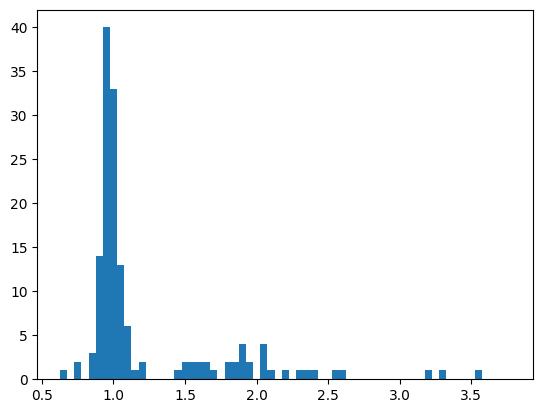

In [55]:
spatial_efficiency = optimal_distances / homings.trajectory_length
plt.hist(spatial_efficiency, bins = np.arange(np.amin(spatial_efficiency), np.amax(spatial_efficiency), 0.05))

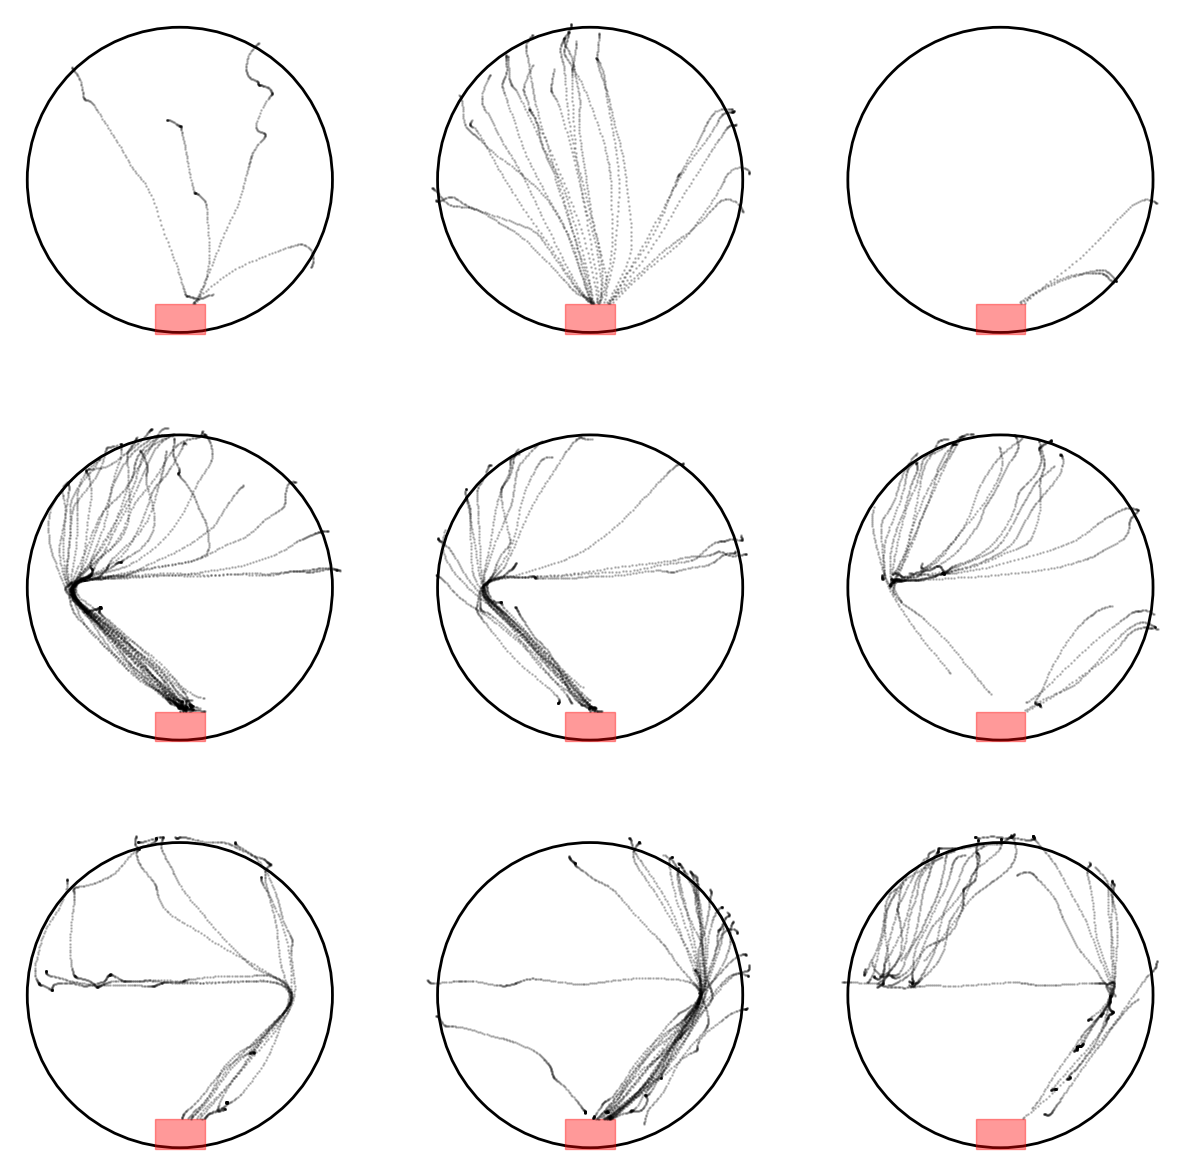

In [57]:
thresh = [.95, 1.05]
spatial_efficiency = optimal_distances / homings.trajectory_length
disc_spatial_efficiency = np.zeros_like(spatial_efficiency)
disc_spatial_efficiency[spatial_efficiency > thresh[0]] += 1
disc_spatial_efficiency[spatial_efficiency > thresh[1]] += 1

fig, axs = plt.subplots(3,3, figsize = (15,15))

for c in cond_list:
    for se in range(3):
        circle = plt.Circle((512, 512), 460, color='k', fill=False, linewidth=2)
        square = patches.Rectangle((437, 886), 150, 90, color='r', alpha=0.4)
        axs[cond_list.index(c), se].add_patch(circle)
        axs[cond_list.index(c), se].add_patch(square)
        h_this_plot = np.where((disc_spatial_efficiency == se) & ([x == c for x in homings.condition]))[0]
        for idx in h_this_plot:
            # compute and plot each trajectory
            x_loc = tracking_data['head_loc'][homings.onset_frames[idx]:homings.offset_frames[idx],0]
            y_loc = tracking_data['head_loc'][homings.onset_frames[idx]:homings.offset_frames[idx],1]
            # crop the points after the mouse has entered the shelter
            in_shelt_y = y_loc > tracking_data['shelter_loc'][0][1]
            in_shelt_x = np.logical_and(x_loc > tracking_data['shelter_loc'][0][0],x_loc < tracking_data['shelter_loc'][1][0])
            in_shelt = np.where(np.logical_and(in_shelt_x, in_shelt_y))[0]
            if len(in_shelt)>0:
                x_loc = x_loc[:in_shelt[0]]
                y_loc = y_loc[:in_shelt[0]]
            axs[cond_list.index(c), se].scatter(x_loc, y_loc, s = 1, color = 'k',alpha = 0.2)
        # Remove ticks and labels for a clean look
        axs[cond_list.index(c), se].set_xlim(0, 1024)
        axs[cond_list.index(c), se].set_ylim(0, 1024)
        axs[cond_list.index(c), se].set_xticks([])
        axs[cond_list.index(c), se].set_yticks([])
        axs[cond_list.index(c), se].set_frame_on(False)
        axs[cond_list.index(c), se].set_aspect('equal')
        axs[cond_list.index(c), se].invert_yaxis()



In [ ]:
"""A syd version of this plot to easily go through all the homings"""
from syd import make_viewer

viewer = make_viewer()
viewer.add_integer("homing", min = 0, max = len(homings.onset_frames)-1)

def plot(state):
    idx = state['homing']
    fig, axs = plt.subplots(1, 1, figsize = (5, 5))
    # compute and plot each trajectory
    x_loc = tracking_data['head_loc'][homings.onset_frames[idx]:homings.offset_frames[idx],0]
    y_loc = tracking_data['head_loc'][homings.onset_frames[idx]:homings.offset_frames[idx],1]
    # crop the points after the mouse has entered the shelter
    in_shelt_y = y_loc > tracking_data['shelter_loc'][0][1]
    in_shelt_x = np.logical_and(x_loc > tracking_data['shelter_loc'][0][0],x_loc < tracking_data['shelter_loc'][1][0])
    in_shelt = np.where(np.logical_and(in_shelt_x, in_shelt_y))[0]
    if len(in_shelt)>0:
        x_loc = x_loc[:in_shelt[0]]
        y_loc = y_loc[:in_shelt[0]]
    axs.scatter(x_loc, y_loc)

    # Add center circle
    circle = plt.Circle((512, 512), 460, color='k', fill=False, linewidth=2)
    axs.add_patch(circle)
    if homings.condition[idx] != 'shelter_only':
        axs.plot([512-280,512+280], [512,512], 'k', linewidth=2)

    # Add red transparent square
    square = patches.Rectangle((437, 886), 150, 90, color='r', alpha=0.4)
    axs.add_patch(square)

    # add optimal trajectory
    plot_optimal_trajectories(homings.onset_frames[idx], tracking_data, homings.condition[idx], interp = 100, ax = axs)

    # compute and display metrics

    text = (
        f"spatial efficiency: {spatial_efficiency[idx]:.3f}"
    )
    axs.text(
        0.02, 0.98, text,
        transform=axs.transAxes,
        va='top', ha='left',
        fontsize=8)
    

    # Remove ticks and labels for a clean look
    axs.set_xlim(0, 1024)
    axs.set_ylim(0, 1024)
    axs.set_xticks([])
    axs.set_yticks([])
    axs.set_frame_on(False)
    axs.set_aspect('equal')
    axs.invert_yaxis()

    return fig

viewer.set_plot(plot)
viewer.show()
# print("homing trajectory length:", homings.trajectory_length[idx])
# print("distance to shelter along optimal path:", dist_to_shelter[0])
# print("spatial efficiency (optimal path length / actual path length):", dist_to_shelter[0] / homings.trajectory_length[idx])



In [9]:
x_pos = np.array([tracking_data['head_loc'][homings.onset_frames[idx],0]])
y_pos = np.array([tracking_data['head_loc'][homings.onset_frames[idx],1]])
condition = [x for x,c in enumerate(cond_list) if c == homings.condition[idx]]
shelter_location = [np.mean([tracking_data['shelter_loc'][0][0],tracking_data['shelter_loc'][1][0]]),
                    tracking_data['shelter_loc'][0][1]]
barrier1 = tracking_data['barrier_loc'][0]
barrier2 = tracking_data['barrier_loc'][1]
dist_to_shelter = compute_dist_shelt(x_pos, y_pos, condition, shelter_location, barrier1, barrier2)
dist_to_shelter, homings.trajectory_length[idx]

(array([818.66772734]), np.float64(917.361414851208))